<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA-ML-DL-Projects/blob/main/AI_BASED_ELECTRICITY_CONSUMPTION_PREDICTION_SYSTEM(PROJECT_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**

Electricity consumption is increasing due to population growth, urbanization, and the widespread use of electrical appliances. Accurately predicting electricity consumption is challenging because it is influenced by multiple factors such as temperature, humidity, occupancy, house size, seasonal variations, and energy usage patterns. Inaccurate predictions can lead to inefficient energy management and increased operational costs.

The aim of this project is to develop an AI-Based Electricity Consumption Prediction System using exploratory data analysis, machine learning, and deep learning techniques. The system analyzes various environmental and household factors to predict electricity consumption accurately. The predicted results can help households, organizations, and energy providers optimize energy usage, improve resource planning, and support efficient energy management decisions.


# **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression

In [ ]:
df=pd.read_csv('/content/electricity_consumption_prediction_dataset_70000_rows.csv')
df.head(5)

,temperature_c,humidity_percent,wind_speed_kmh,occupancy_hours,number_of_appliances,house_size_sqft,number_of_residents,day_of_week,month,season,building_type,renewable_energy,holiday,electricity_price_per_kwh,electricity_consumption_kwh
0,26.2,23.2,3.8,4,19,1215,1,Sunday,Dec,Winter,Apartment,No,No,5.25,451.22
1,43.5,82.1,23.2,7,15,1207,2,Saturday,Feb,Summer,Office,Yes,No,10.76,700.32
2,37.0,38.7,18.5,4,2,3091,8,Saturday,Feb,Winter,Apartment,Yes,No,9.07,582.28
3,33.0,41.3,19.4,1,15,645,8,Thursday,Mar,Spring,Office,Yes,Yes,4.28,546.22
4,19.7,37.0,7.4,7,18,2079,3,Thursday,Feb,Winter,Office,Yes,Yes,6.32,675.50


In [ ]:
target='electricity_consumption_kwh'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_c                70000 non-null  float64
 1   humidity_percent             70000 non-null  float64
 2   wind_speed_kmh               70000 non-null  float64
 3   occupancy_hours              70000 non-null  int64  
 4   number_of_appliances         70000 non-null  int64  
 5   house_size_sqft              70000 non-null  int64  
 6   number_of_residents          70000 non-null  int64  
 7   day_of_week                  70000 non-null  object 
 8   month                        70000 non-null  object 
 9   season                       70000 non-null  object 
 10  building_type                70000 non-null  object 
 11  renewable_energy             70000 non-null  object 
 12  holiday                      70000 non-null  object 
 13  electricity_pric

In [ ]:
df.isnull().sum()

,0
temperature_c,0
humidity_percent,0
wind_speed_kmh,0
occupancy_hours,0
number_of_appliances,0
house_size_sqft,0
number_of_residents,0
day_of_week,0
month,0
season,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(70000, 15)

In [ ]:
df.columns

Index(['temperature_c', 'humidity_percent', 'wind_speed_kmh',
       'occupancy_hours', 'number_of_appliances', 'house_size_sqft',
       'number_of_residents', 'day_of_week', 'month', 'season',
       'building_type', 'renewable_energy', 'holiday',
       'electricity_price_per_kwh', 'electricity_consumption_kwh'],
      dtype='object')

In [ ]:
df['electricity_consumption_kwh'].value_counts()

,count
electricity_consumption_kwh,
759.40,9
651.31,8
759.07,8
688.92,7
783.10,7
...,...
390.34,1
307.61,1
334.50,1


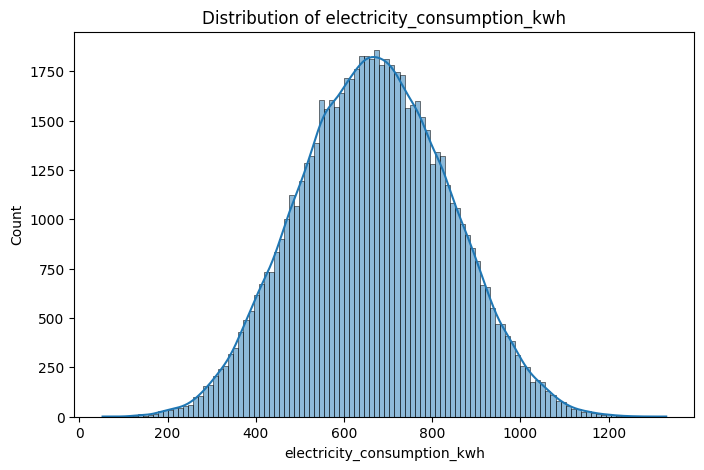

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['electricity_consumption_kwh'],kde=True)
plt.title('Distribution of electricity_consumption_kwh')
plt.show()

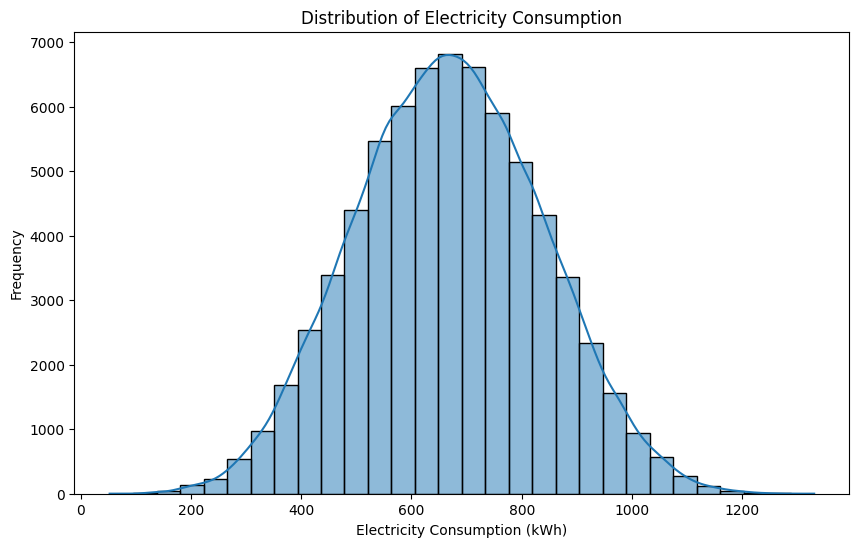

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["electricity_consumption_kwh"], bins=30, kde=True)
plt.title("Distribution of Electricity Consumption")
plt.xlabel("Electricity Consumption (kWh)")
plt.ylabel("Frequency")
plt.show()

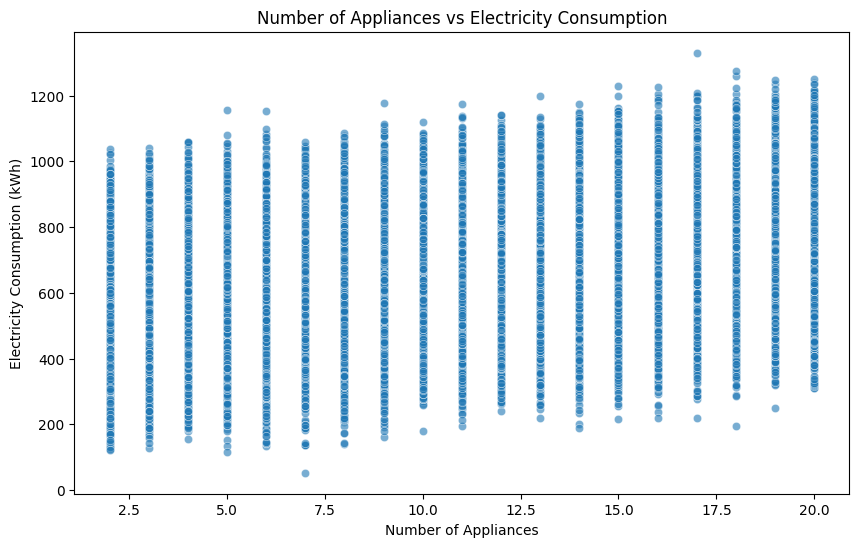

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="number_of_appliances",
    y="electricity_consumption_kwh",
    alpha=0.6
)
plt.title("Number of Appliances vs Electricity Consumption")
plt.xlabel("Number of Appliances")
plt.ylabel("Electricity Consumption (kWh)")
plt.show()

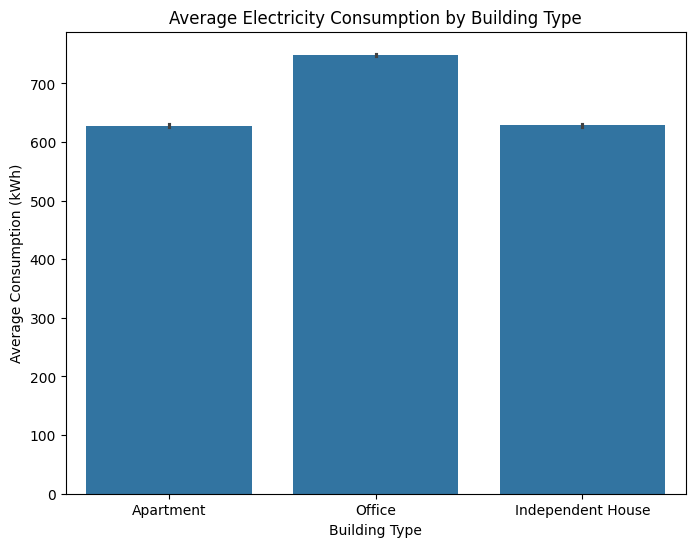

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df,
    x="building_type",
    y="electricity_consumption_kwh"
)
plt.title("Average Electricity Consumption by Building Type")
plt.xlabel("Building Type")
plt.ylabel("Average Consumption (kWh)")
plt.show()

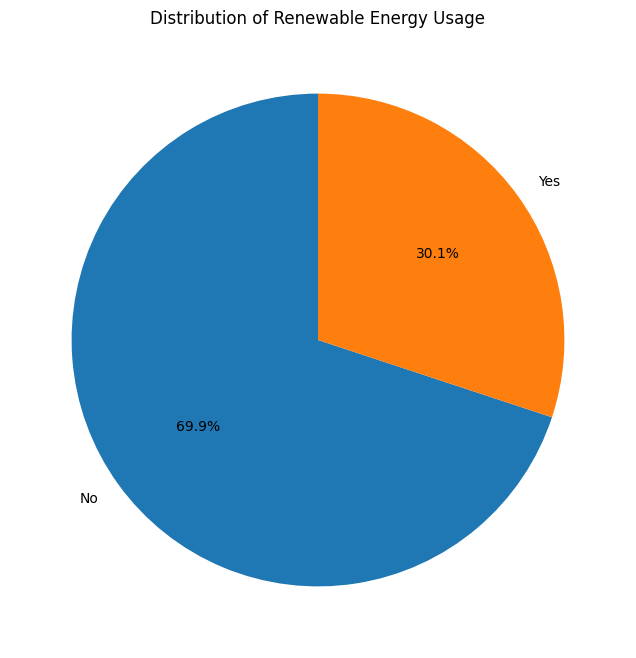

In [ ]:
renewable_counts = df["renewable_energy"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    renewable_counts,
    labels=renewable_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Renewable Energy Usage")
plt.show()

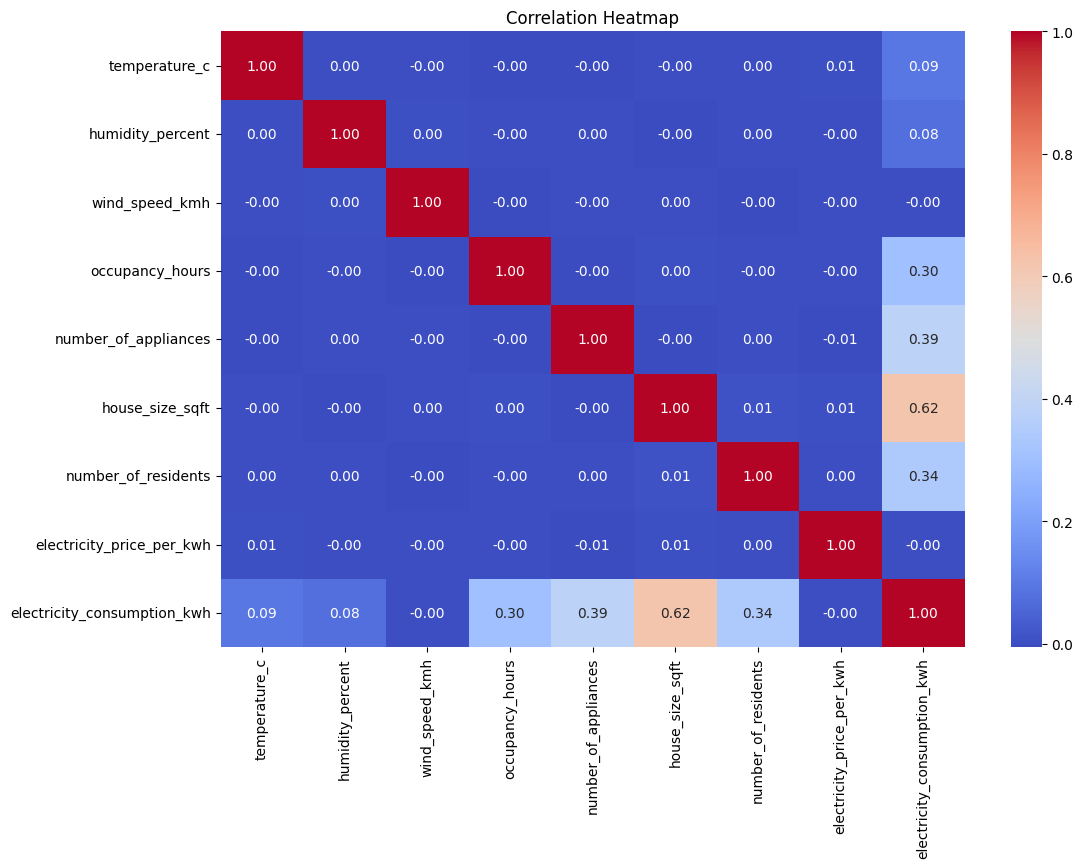

In [ ]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

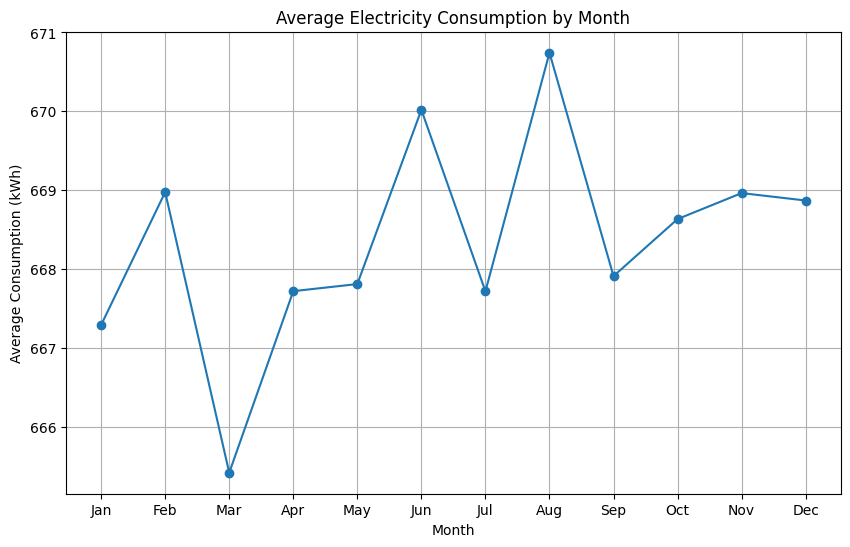

In [ ]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_avg = (
    df.groupby("month")["electricity_consumption_kwh"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Average Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Consumption (kWh)")
plt.grid(True)
plt.show()

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['temperature_c', 'humidity_percent', 'wind_speed_kmh',
       'occupancy_hours', 'number_of_appliances', 'house_size_sqft',
       'number_of_residents', 'electricity_price_per_kwh',
       'electricity_consumption_kwh'],
      dtype='object')

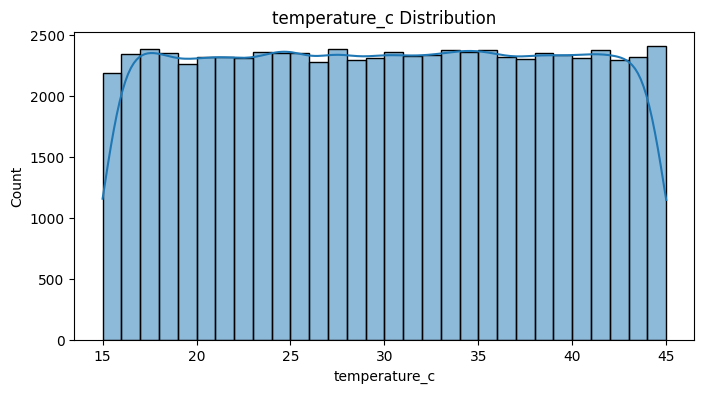

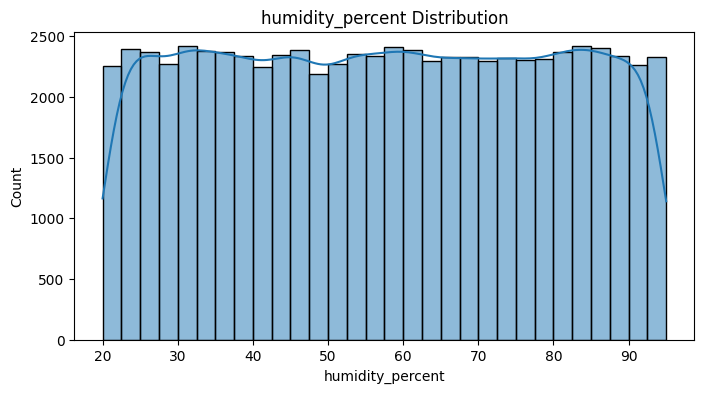

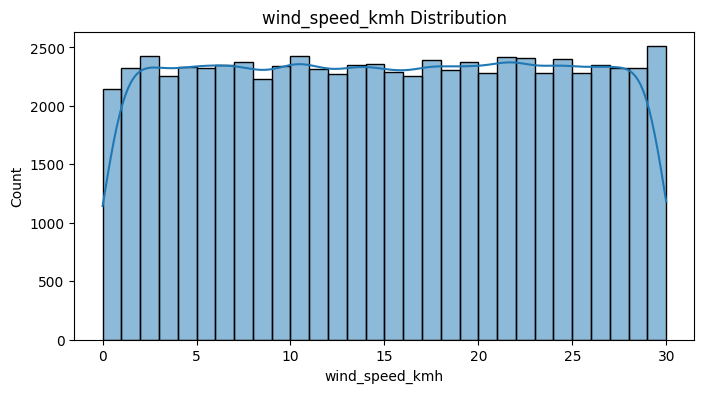

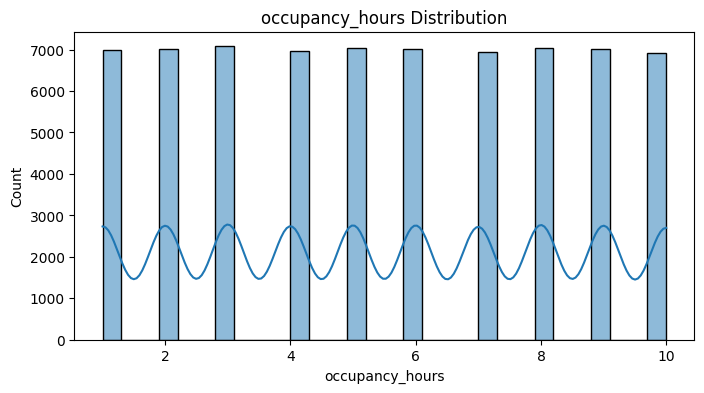

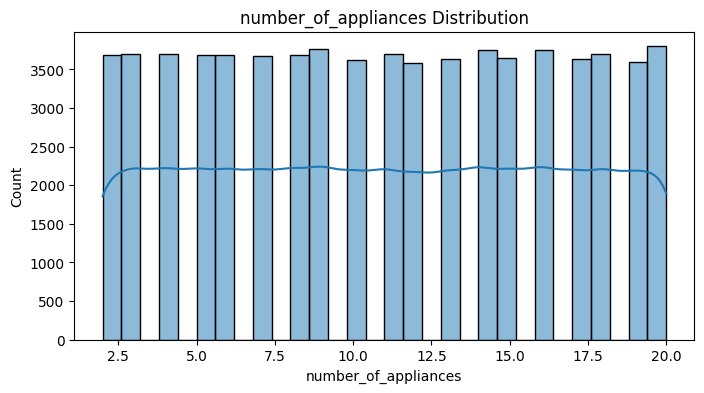

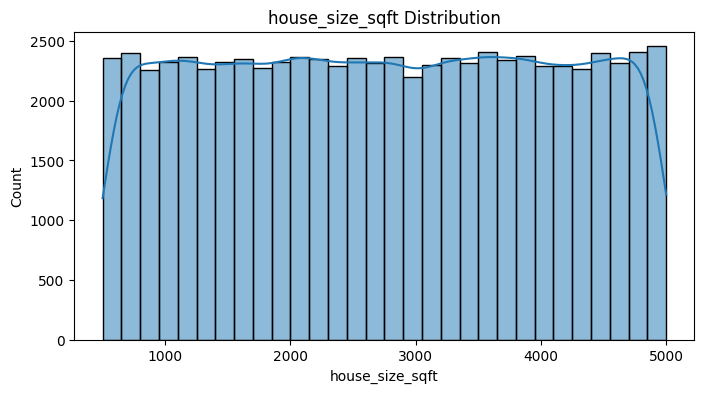

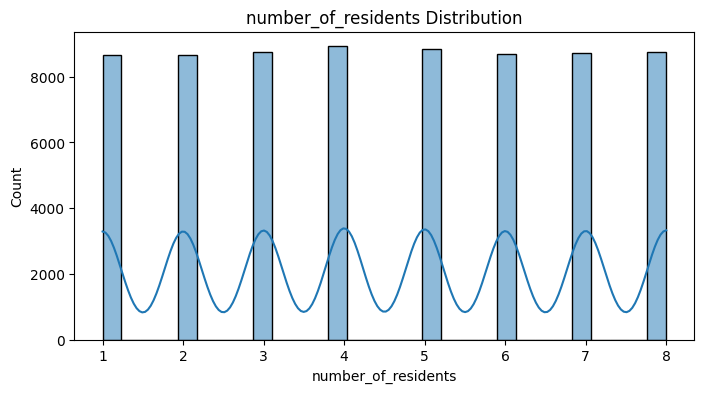

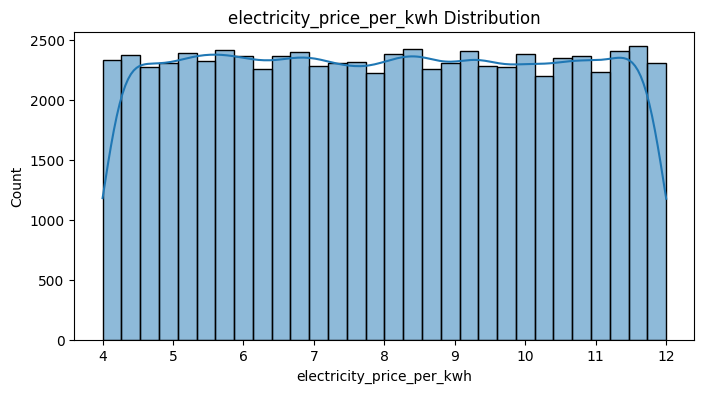

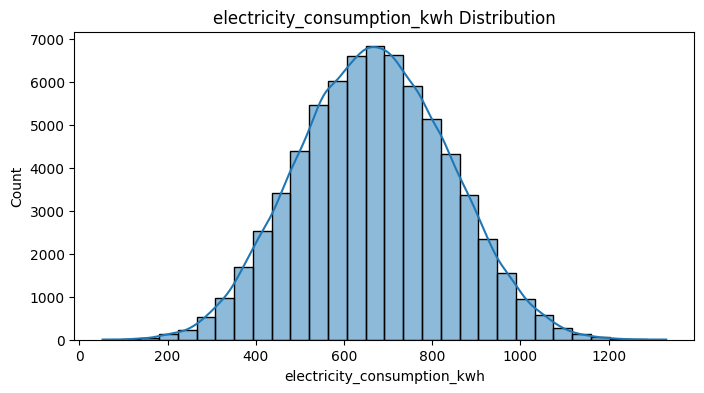

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['day_of_week', 'month', 'season', 'building_type', 'renewable_energy',
       'holiday'],
      dtype='object')

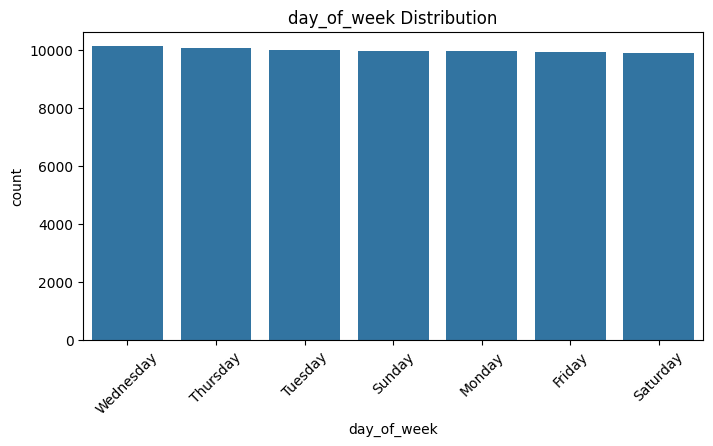

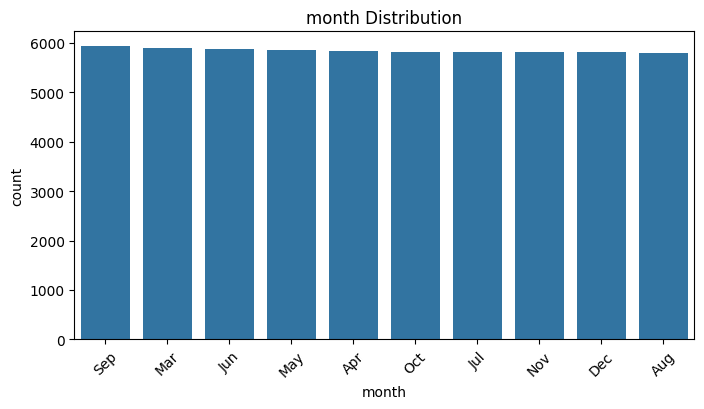

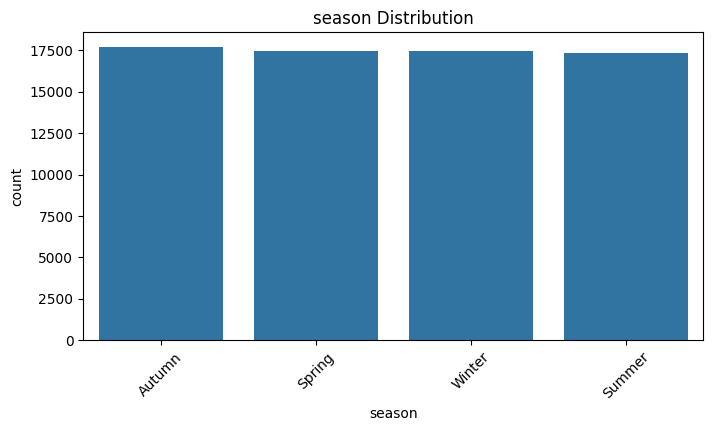

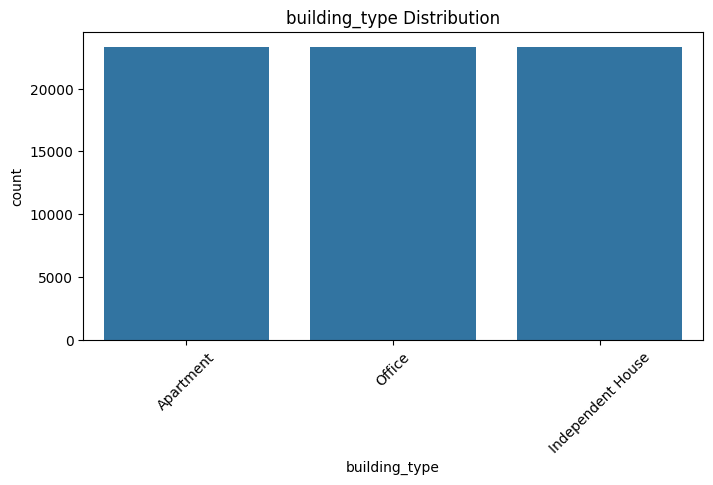

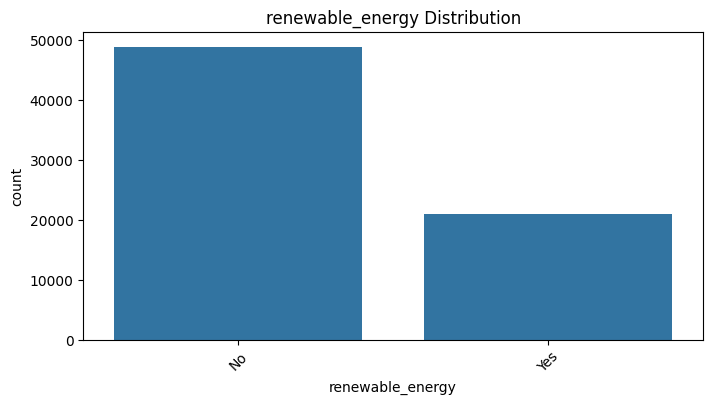

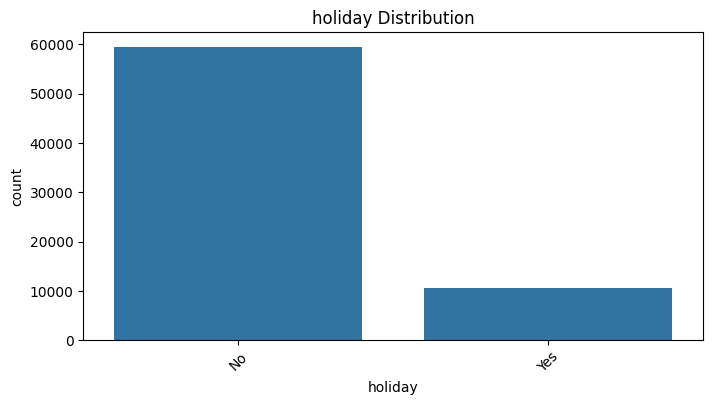

In [ ]:
for col in categorical_cols:
  plt.figure(figsize=(8,4))
  sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
  plt.xticks(rotation=45)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_c                70000 non-null  float64
 1   humidity_percent             70000 non-null  float64
 2   wind_speed_kmh               70000 non-null  float64
 3   occupancy_hours              70000 non-null  int64  
 4   number_of_appliances         70000 non-null  int64  
 5   house_size_sqft              70000 non-null  int64  
 6   number_of_residents          70000 non-null  int64  
 7   day_of_week                  70000 non-null  object 
 8   month                        70000 non-null  object 
 9   season                       70000 non-null  object 
 10  building_type                70000 non-null  object 
 11  renewable_energy             70000 non-null  object 
 12  holiday                      70000 non-null  object 
 13  electricity_pric

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["building_type"]=le.fit_transform(df["building_type"])
df["renewable_energy"]=le.fit_transform(df["renewable_energy"])
df["holiday"]=le.fit_transform(df["holiday"])

In [ ]:
print(df['day_of_week'].unique())

['Sunday' 'Saturday' 'Thursday' 'Tuesday' 'Friday' 'Monday' 'Wednesday']


In [ ]:
print(df['month'].unique())

['Dec' 'Feb' 'Mar' 'Jul' 'Apr' 'Nov' 'Sep' 'Jan' 'Oct' 'May' 'Aug' 'Jun']


In [ ]:
print(df['season'].unique())

['Winter' 'Summer' 'Spring' 'Autumn']


In [ ]:
df['day_of_week'].replace(['Sunday','Saturday','Thursday','Tuesday','Friday','Monday','Wednesday'],[0,1,2,3,4,5,6],inplace=True)
df['month'].replace(['Dec','Feb','Mar','Jul','Apr','Nov','Sep','Jan','Oct','May','Aug','Jun'],[0,1,2,3,4,5,6,7,8,9,10,11],inplace=True)
df['season'].replace(['Winter','Summer','Spring','Autumn'],[0,1,2,3],inplace=True)

/tmp/ipykernel_680/3236559943.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['day_of_week'].replace(['Sunday','Saturday','Thursday','Tuesday','Friday','Monday','Wednesday'],[0,1,2,3,4,5,6],inplace=True)
/tmp/ipykernel_680/3236559943.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['day

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_c                70000 non-null  float64
 1   humidity_percent             70000 non-null  float64
 2   wind_speed_kmh               70000 non-null  float64
 3   occupancy_hours              70000 non-null  int64  
 4   number_of_appliances         70000 non-null  int64  
 5   house_size_sqft              70000 non-null  int64  
 6   number_of_residents          70000 non-null  int64  
 7   day_of_week                  70000 non-null  int64  
 8   month                        70000 non-null  int64  
 9   season                       70000 non-null  int64  
 10  building_type                70000 non-null  int64  
 11  renewable_energy             70000 non-null  int64  
 12  holiday                      70000 non-null  int64  
 13  electricity_pric

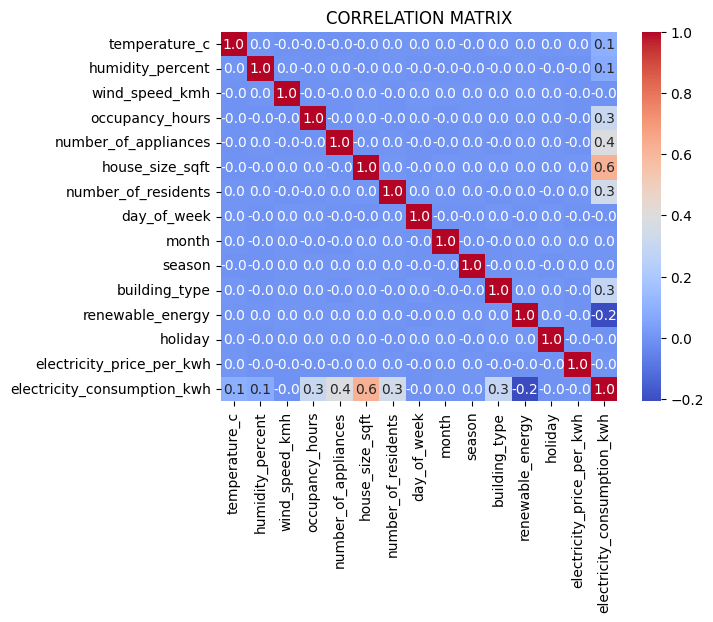

In [ ]:
corr_matrix=df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('CORRELATION MATRIX')
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)['electricity_consumption_kwh']
print(corr.sort_values(ascending=False))

electricity_consumption_kwh    1.000000
house_size_sqft                0.620296
number_of_appliances           0.385079
number_of_residents            0.340130
occupancy_hours                0.303194
building_type                  0.291328
temperature_c                  0.092819
humidity_percent               0.075584
month                          0.003418
season                         0.001543
electricity_price_per_kwh     -0.000275
holiday                       -0.000550
day_of_week                   -0.000631
wind_speed_kmh                -0.001485
renewable_energy              -0.208049
Name: electricity_consumption_kwh, dtype: float64


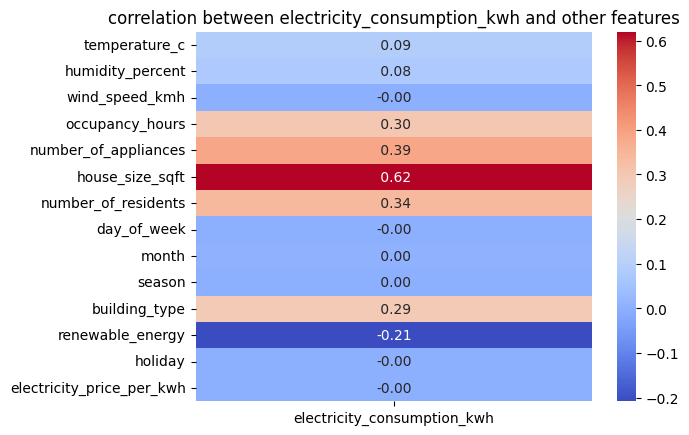

In [ ]:
status_corr=df.corr()["electricity_consumption_kwh"]
status_corr=status_corr.drop("electricity_consumption_kwh")
sns.heatmap(status_corr.to_frame(), annot=True,fmt=' .2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between electricity_consumption_kwh and other features')
plt.show()

In [ ]:
df.columns

Index(['temperature_c', 'humidity_percent', 'wind_speed_kmh',
       'occupancy_hours', 'number_of_appliances', 'house_size_sqft',
       'number_of_residents', 'day_of_week', 'month', 'season',
       'building_type', 'renewable_energy', 'holiday',
       'electricity_price_per_kwh', 'electricity_consumption_kwh'],
      dtype='object')

In [ ]:
df.drop(['wind_speed_kmh','day_of_week','holiday','month'],axis=1,inplace=True)

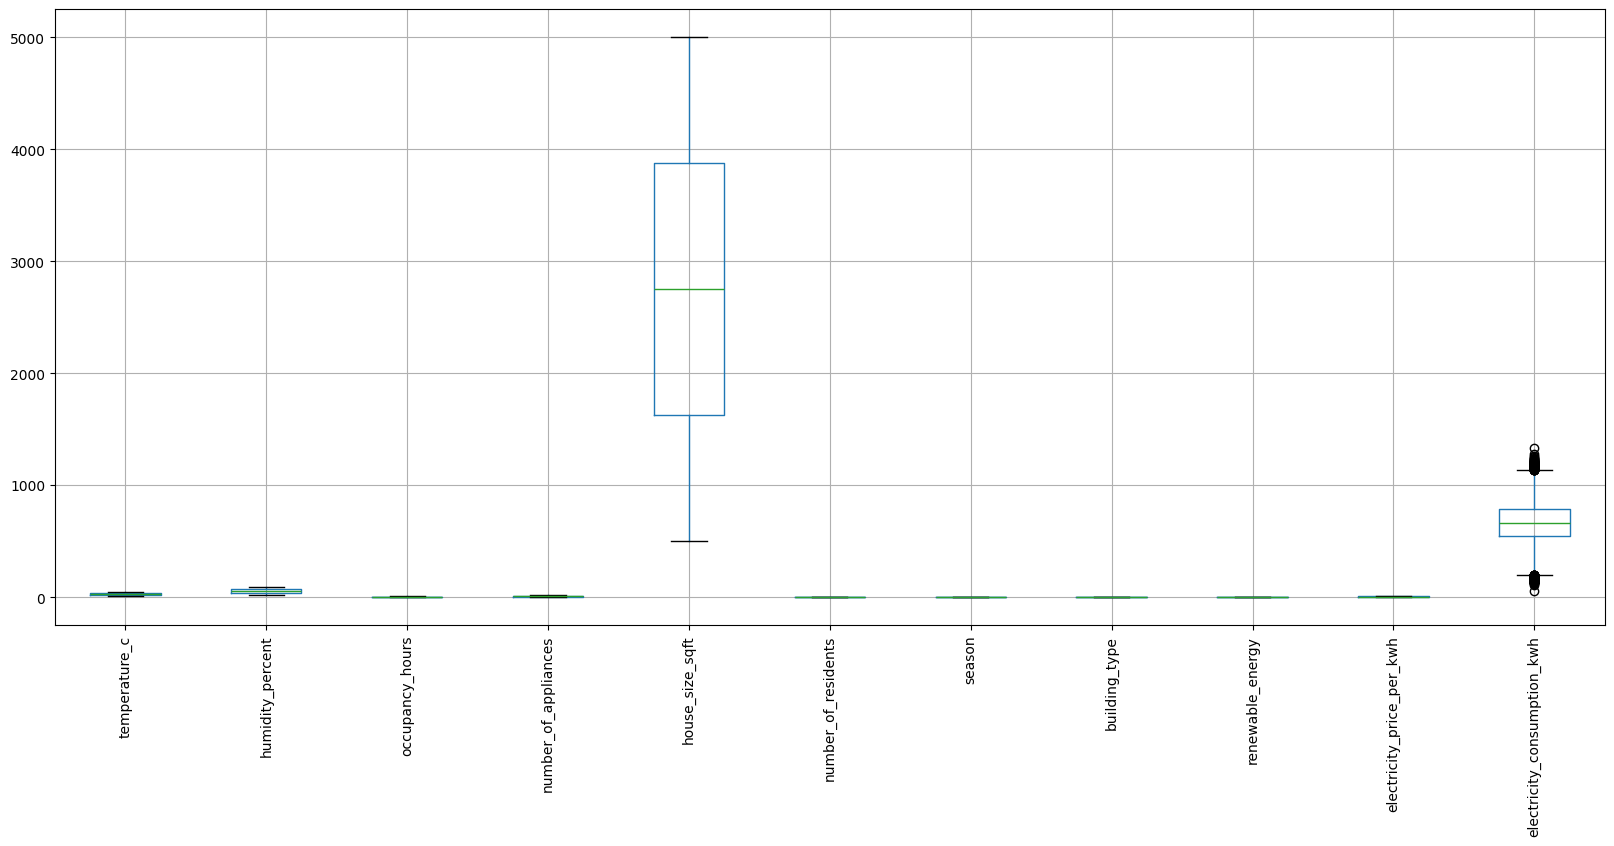

In [ ]:
df.boxplot(figsize=(20,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.shape

(70000, 11)

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df
df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(70000, 11)

In [ ]:
df.columns

Index(['temperature_c', 'humidity_percent', 'occupancy_hours',
       'number_of_appliances', 'house_size_sqft', 'number_of_residents',
       'season', 'building_type', 'renewable_energy',
       'electricity_price_per_kwh', 'electricity_consumption_kwh'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['temperature_c', 'humidity_percent', 'occupancy_hours',
       'number_of_appliances', 'house_size_sqft', 'number_of_residents',
       'season', 'building_type', 'renewable_energy',
       'electricity_price_per_kwh']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

# **MACHINE LEARNING**

In [ ]:
x=df[['temperature_c', 'humidity_percent', 'occupancy_hours',
       'number_of_appliances', 'house_size_sqft', 'number_of_residents',
       'season', 'building_type', 'renewable_energy',
       'electricity_price_per_kwh']]
y=df['electricity_consumption_kwh']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.88


In [ ]:
#DecisionTree

from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.77


In [ ]:
#SVR(SVM)

from sklearn.svm import SVR
model=SVR(kernel="poly",degree=8)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.30


In [ ]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.89


In [ ]:
# GRADIENTBOOSTER
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create model
gb_model = GradientBoostingRegressor(random_state=42)

# Train model
gb_model.fit(x_train, y_train)

# Predict
y_pred_gb = gb_model.predict(x_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

R² Score: 0.9049198306028146
MAE: 41.73580998429023
RMSE: 52.15042770643414


In [ ]:
# ADABOOST

from sklearn.ensemble import AdaBoostRegressor

model=AdaBoostRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.84


In [ ]:
# XGBOOST

from  xgboost import XGBRegressor
model=XGBRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.90


# **K-FOLD CROSS VALIDATION**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df.drop('electricity_consumption_kwh', axis=1)
y = df['electricity_consumption_kwh']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

best_r2 = -np.inf
best_fold = -1

best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):

    print(f"\nFold {fold}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("R² Score:", r2)
    print("RMSE:", rmse)

    if r2 > best_r2:

        best_r2 = r2
        best_fold = fold

        best_X_train = X_train
        best_y_train = y_train

        best_X_test = X_test
        best_y_test = y_test

        best_y_pred = y_pred

print(f"\nBest Fold: {best_fold} with R² Score: {best_r2}")


Fold 1
R² Score: 0.8851146914225436
RMSE: 57.43331237518315

Fold 2
R² Score: 0.882689730289043
RMSE: 57.488499284803545

Fold 3
R² Score: 0.8839926682409838
RMSE: 57.30565797998608

Fold 4
R² Score: 0.8838574180068137
RMSE: 57.64033156112459

Fold 5
R² Score: 0.88560612319394
RMSE: 57.53920888904671

Best Fold: 5 with R² Score: 0.88560612319394


In [ ]:
model=LinearRegression()
model.fit(best_X_train,best_y_train)
print("Linear Regression:",model.score(best_X_test,best_y_test))

Linear Regression: 0.88560612319394


In [ ]:
model=DecisionTreeRegressor()
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 0.7825191522931533


In [ ]:
model=SVR()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.39536212903092893


In [ ]:
model=RandomForestRegressor()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 0.8957297968612881


In [ ]:
model=GradientBoostingRegressor(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 0.906457918429012


In [ ]:
model=AdaBoostRegressor()
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 0.8498815063136189


In [ ]:
model=XGBRegressor()
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 0.9023944258754243


# **DEEP LEARNING**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# Scale the data for deep learning
scaler_dl = MinMaxScaler()

x_train_scaled_dl = scaler_dl.fit_transform(best_X_train)
x_test_scaled_dl = scaler_dl.transform(best_X_test)

# Model
model = Sequential()
model.add(Dense(110, input_shape=(x_train_scaled_dl.shape[1],), activation='relu'))  # Hidden Layer 1
model.add(Dense(44, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(1))

# Compile with regression metrics
model.compile(optimizer=Adam(learning_rate=0.001), # Adjusted learning rate for better convergence
              loss='mean_squared_error')

# Train
model.fit(x_train_scaled_dl, best_y_train, epochs=50, batch_size=32, verbose=0) # Increased epochs and added batch_size

# Predict
y_pred = model.predict(x_test_scaled_dl)

# Calculate MSE and MAE
mse = mean_squared_error(best_y_test, y_pred)
mae = mean_absolute_error(best_y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Mean Squared Error: 2534.3186739610496
Mean Absolute Error: 40.2253932295445


# **CONCLUSION**
This project developed an AI-Based Electricity Consumption Prediction System using Exploratory Data Analysis (EDA), machine learning, and deep learning techniques to predict electricity consumption based on factors such as temperature, humidity, occupancy, house size, and the number of appliances. Data preprocessing and analysis were performed to understand the relationships between variables and improve the predictive performance of the models.

Among all the machine learning models, Gradient Boosting achieved the highest R² score of 0.9065, followed closely by XGBoost with 0.9024 and Random Forest with 0.8957. Linear Regression also performed well with an R² score of 0.8856, while Decision Tree and SVM showed comparatively lower performance. The deep learning model produced a Mean Squared Error (MSE) of 2534.32 and a Mean Absolute Error (MAE) of 40.23, indicating good prediction accuracy with relatively low error. The results demonstrate that AI techniques can effectively predict electricity consumption and support efficient energy management and planning.

# **FUTURE SCOPE**

In the future, this project can be enhanced by using larger real-world smart meter datasets and incorporating additional factors such as weather forecasts, appliance-level energy usage, occupancy schedules, and electricity demand patterns. These improvements can further increase prediction accuracy and make the system more robust.

The system can also be integrated into smart home and smart grid applications to provide real-time electricity consumption forecasts and energy-saving recommendations. Advanced deep learning models and explainable AI techniques can be implemented to improve prediction performance and help users better understand the factors influencing electricity consumption patterns.